In [2]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

In [4]:
fp32_path = "../../../full_precision/forgeting/experiments"


# Attack forg ep

In [37]:
expath = '../attack_forg_ep'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_ep.parquet'))

# attach also baseline
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_ep/attack_forg_ep.parquet")) [['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '7b_ep0', '7b_ep0_em', '7b_ep0_bleu', '7b_ep0_meteor',
       '7b_ep0_rougeL', '7b_ep1', '7b_ep1_em', '7b_ep1_bleu',
       '7b_ep1_meteor', '7b_ep1_rougeL', '7b_ep2', '7b_ep2_em',
       '7b_ep2_bleu', '7b_ep2_meteor', '7b_ep2_rougeL', '7b_ep3',
       '7b_ep3_em', '7b_ep3_bleu', '7b_ep3_meteor', '7b_ep3_rougeL']]

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')


### LoRA

In [38]:
merged_df.columns

Index(['prefix_250', 'prefix_200', 'prefix_150', 'prefix_100', 'suffix',
       '7b_lo_ep1', '7b_lo_ep1_em', '7b_lo_ep1_bleu', '7b_lo_ep1_meteor',
       '7b_lo_ep1_rougeL', '7b_lo_ep2', '7b_lo_ep2_em', '7b_lo_ep2_bleu',
       '7b_lo_ep2_meteor', '7b_lo_ep2_rougeL', '7b_lo_ep3', '7b_lo_ep3_em',
       '7b_lo_ep3_bleu', '7b_lo_ep3_meteor', '7b_lo_ep3_rougeL', '7b_ep0',
       '7b_ep0_em', '7b_ep0_bleu', '7b_ep0_meteor', '7b_ep0_rougeL', '7b_ep1',
       '7b_ep1_em', '7b_ep1_bleu', '7b_ep1_meteor', '7b_ep1_rougeL', '7b_ep2',
       '7b_ep2_em', '7b_ep2_bleu', '7b_ep2_meteor', '7b_ep2_rougeL', '7b_ep3',
       '7b_ep3_em', '7b_ep3_bleu', '7b_ep3_meteor', '7b_ep3_rougeL'],
      dtype='object')

In [39]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'7b_lo_{ep}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

lo_means = pd.DataFrame(mean_data, index=eps)
lo_means

,em,bleu,meteor,rougeL
ep1,0.226,57.174912,0.648102,0.616498
ep2,0.224,56.867945,0.646405,0.614998
ep3,0.218,56.948035,0.647483,0.615881


In [40]:
# baseline_means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
eps = ['ep0', 'ep1', 'ep2', 'ep3']

mean_data = {}


for metric in metrics:
    mean_data[metric] = []
    for ep in eps:
        column_name = f'7b_{ep}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

base_means = pd.DataFrame(mean_data, index=eps)
base_means

,em,bleu,meteor,rougeL
ep0,0.395,66.350866,0.719665,0.694137
ep1,0.015,38.141352,0.524810,0.483296
ep2,0.110,46.088452,0.566051,0.527461
ep3,0.116,46.953106,0.572044,0.533803


## Visuals


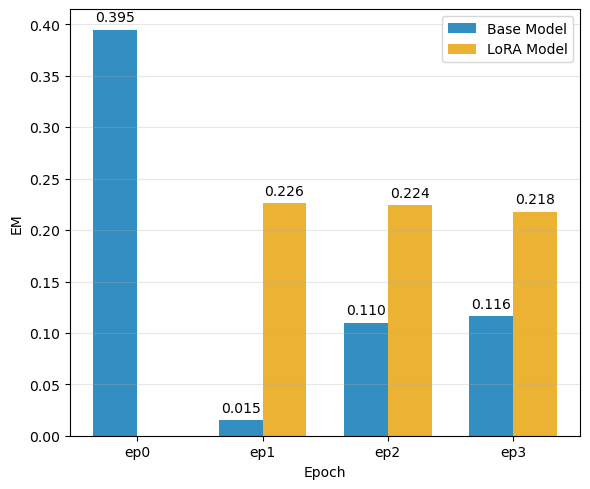

In [41]:
from matplotlib.lines import Line2D
from cycler import cycler

import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 5))

# EM data for both models
base_em = [base_means.loc[ep, 'em'] for ep in eps]
lo_em = [lo_means.loc[ep, 'em'] for ep in ['ep1', 'ep2', 'ep3']]  # lo_means doesn't have ep0

# Bar positions and width
x_pos = np.arange(len(eps))
bar_width = 0.35

# Plot base model EM
base_bars = ax.bar(x_pos - bar_width/2, base_em, bar_width, 
                   label='Base Model', color='#0072B2', alpha=0.8)

# Plot LoRA model EM (starting from ep1)
lo_bars = ax.bar(x_pos[1:] + bar_width/2, lo_em, bar_width, 
                 label='LoRA Model', color='#E69F00', alpha=0.8)

# Customize the plot
ax.set_xlabel('Epoch')
ax.set_ylabel('EM')
# ax.set_title('Exact Match Performance: Base vs LoRA Model')
ax.set_xticks(x_pos)
ax.set_xticklabels(eps)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [base_bars, lo_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

fig.savefig('./lo_attack_forg_ep.pdf', format='pdf')

# Attack forg plen

In [5]:
expath = '../attack_forg_plen'
# results dataset
df = pd.read_parquet(os.path.join(expath,'attack_forg_plen.parquet'))

# attach also fp32
df_fp32 = pd.read_parquet(os.path.join(fp32_path, "attack_forg_plen/attack_forg_plen.parquet"))

merged_df = pd.merge(df, df_fp32,
  on=['prefix_250', 'prefix_200',
  'prefix_150', 'prefix_100', 'suffix'],
  how='inner')

In [32]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'7b_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_fp32_absolute = pd.DataFrame(mean_data, index=plens)
plen_fp32_absolute

,em,bleu,meteor,rougeL
p100,0.116,46.953106,0.572044,0.533803
p150,0.150,52.447396,0.615700,0.581515
p200,0.171,54.607682,0.631366,0.599248
p250,0.178,56.036862,0.642300,0.612785


In [33]:
# With the baseline

# compute the baselines
mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'7b_{eps[0]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

plen_fp32_ep0 = pd.DataFrame(mean_data, index=plens)
plen_fp32_baseline = plen_fp32_absolute.subtract(plen_fp32_ep0)
plen_fp32_baseline

,em,bleu,meteor,rougeL
p100,-0.279,-19.397761,-0.147621,-0.160333
p150,-0.302,-18.540148,-0.141045,-0.152364
p200,-0.314,-18.462455,-0.140814,-0.154554
p250,-0.320,-18.194811,-0.139404,-0.150974


In [20]:
# merged_df.columns
pd.DataFrame(mean_data)

,em,bleu,meteor,rougeL
0,0.218,56.948035,0.647483,0.615881
1,0.287,61.168264,0.680371,0.652684
2,0.307,63.444363,0.697687,0.673327
3,0.328,64.849173,0.707802,0.685226


In [25]:
# Extract and calculate means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'7b_lo_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

lo_means = pd.DataFrame(mean_data, index=plens)
lo_means

,em,bleu,meteor,rougeL
p100,0.218,56.948035,0.647483,0.615881
p150,0.287,61.168264,0.680371,0.652684
p200,0.307,63.444363,0.697687,0.673327
p250,0.328,64.849173,0.707802,0.685226


In [24]:
# baseline_means
metrics = ['em', 'bleu', 'meteor', 'rougeL']
plens = ['p100', 'p150', 'p200', 'p250']
eps = ['ep0', 'ep3']

mean_data = {}

for metric in metrics:
    mean_data[metric] = []
    for plen in plens:
        column_name = f'7b_{eps[1]}_{plen}_{metric}'
        mean_value = merged_df[column_name].mean()
        mean_data[metric].append(mean_value)

base_means = pd.DataFrame(mean_data, index=plens)
base_means

,em,bleu,meteor,rougeL
p100,0.116,46.953106,0.572044,0.533803
p150,0.150,52.447396,0.615700,0.581515
p200,0.171,54.607682,0.631366,0.599248
p250,0.178,56.036862,0.642300,0.612785


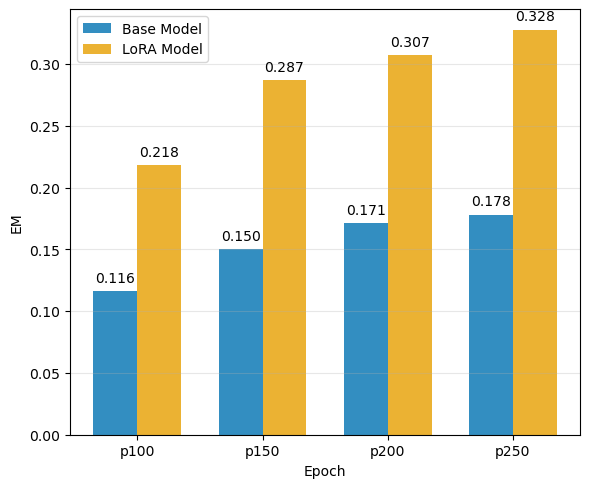

In [33]:
from matplotlib.lines import Line2D
from cycler import cycler

import matplotlib.pyplot as plt
import numpy as np

# Set up the plot
fig, ax = plt.subplots(figsize=(6, 5))
plens = ['p100', 'p150', 'p200', 'p250']

# EM data for both models
base_em = [base_means.loc[pl, 'em'] for pl in plens]
lo_em = [lo_means.loc[pl, 'em'] for pl in plens]  

# Bar positions and width
x_pos = np.arange(len(plens))
bar_width = 0.35

# Plot base model EM
base_bars = ax.bar(x_pos - bar_width/2, base_em, bar_width, 
                   label='Base Model', color='#0072B2', alpha=0.8)

# Plot LoRA model EM (starting from ep1)
lo_bars = ax.bar(x_pos + bar_width/2, lo_em, bar_width, 
                 label='LoRA Model', color='#E69F00', alpha=0.8)

# Customize the plot
ax.set_xlabel('Epoch')
ax.set_ylabel('EM')
# ax.set_title('Exact Match Performance: Base vs LoRA Model')
ax.set_xticks(x_pos)
ax.set_xticklabels(plens)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for bars in [base_bars, lo_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

fig.savefig('./lo_plen_forg_ep.pdf', format='pdf')